In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from scipy.special import expit

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 14})

SEED = 314159
TRAIN_TEST_SPLIT = 0.80

data_path = "D:\data\ml"

# Калибровка вероятностей

Часто при обучении моделей для бинарной классификации хочется получать не только предсказанную метку класса, но и вероятность положительного класса. Предсказанная вероятность может служить как мера уверенности нашего алгоритма. Также это позволяет сравнивать две модели, у которых одинаковые метрики точности. Этот тип метрик конкретно используется в высокорисковых приложениях, позволяя нам не рассматривать результаты модели как реальные вероятности, а вместо этого выходить за рамки необработанных результатов и предотвращать плохое принятие решений или ложную интерпретацию.

В задаче бинарной классификации откалиброванным алгоритмом называют такой алгоритм, для которого доля положительных примеров (на основе реальных меток классов) для предсказаний в окрестности произвольной вероятности $\hat p$ совпадает с этим значением $p$. Например, если взять объекты, для которых предсказанные вероятности близки к 0.7, то окажется, что среди них 70\% принадлежат положительному классу.
На математическом языке это выглядит так: если $\hat p$  — предсказанная вероятность класса 1, то $P(y=1|q(x_i)=\hat p)=\hat p$.

Однако некоторые алгоритмы не выдают корректные вероятности классов. В таком случае вероятности модели нужно калибровать.

Для визуализации откалиброванности алгоритма можно построить калибровочную кривую. На этой кривой абсцисса точки соответствуют значению $p$ (предсказаний алгоритма), а ордината соответствует доле примеров, для которых алгоритм предсказал вероятность, близкую к $p$. В идеальном случае эта кривая совпадает с прямой $y = x$. 

Чаще всего  $\hat p$ - это какие-то вещественные числа, которые будут разными для разных $y_i$. Для того, чтобы оценить именно вероятности, отрезок $[0, 1]$ можно разбить на бины, и для каждого бина вычислить долю класса 1 и,соответственно, среднюю предсказанную вероятность.

Пример диаграммы калибровки: 

![calib_1](../additional_materials/images/calib_1.png)


У идеально откалиброванной модели зеленая и розовая линии должны совпадать. Однако в нашем случае модель завышает свою оценку. Как отделить положительные примеры от отрицательных (дать дискретный класс)? Обычно пользуются порогом (логично сделать 0.5). Но нам придется сдвинуть порог вправо - так, чтобы разбить зеленый график пополам по вертикали.

Часто картинка иная. В таком случае говорят о слишком увернной модели (overconfident) или неуверенной (underconfident). В первом случае молдель предсказывает вероятности ближе к экстремальным, ченм стоит (0.1 вместо 0.2 и 0.9 вместо 0.1), во втором же наоборот, сводит все вероятности к центру интервала.

![calib_2](../additional_materials/images/calib_2.png)

Часто слишком большой уверенностью грешат нейросети, так как их учат именно на метках классов. Способ с этим бороться - Label smoothing, когда вместо метки класса модели дают слегка сглаженное значение (0.9 вместо 1, и т.д.). Альтернативный путь - hard samples mining, когда мы заставляем модель больше обращать внимания на объекты ближе к границе разделения.

Второй же случай возникает, если мы, наоборот, слишком сильно уделяем внимание границе. Это часто происходит в SVM или бэггинге.

Ниже на синтетическом примере посмотрим на типичные калибровочные кривые для overconfident и underconfident моделей: генерируем данные с нелинейной границей, получаем «предсказания» и искусственно искажаем их к экстремумам или к центру интервала. Кроме того, рассмотрим случай, когда модель предсказывает отношение классов, не зависящее от х.

In [2]:
from sklearn.datasets import make_moons

X_syn, y_syn = make_moons(n_samples=2000, noise=0.25, random_state=SEED)
X_tr, X_te, y_tr, y_te = train_test_split(X_syn, y_syn, test_size=0.4, random_state=SEED)
clf_syn = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
p_real = np.clip(clf_syn.predict_proba(X_te)[:, 1], 1e-6, 1 - 1e-6)

def logit(p: np.ndarray) -> np.ndarray:
    return np.log(p / (1 - p))
    
# to get new probabilities we need to make more strict logits and then return back to probas
p_over = 1. / (1 + np.exp(-5 * logit(p_real))) 
p_under = 0.5 + 0.35 * (p_real - 0.5)
p_constant = np.full_like(p_real, y_te.mean())

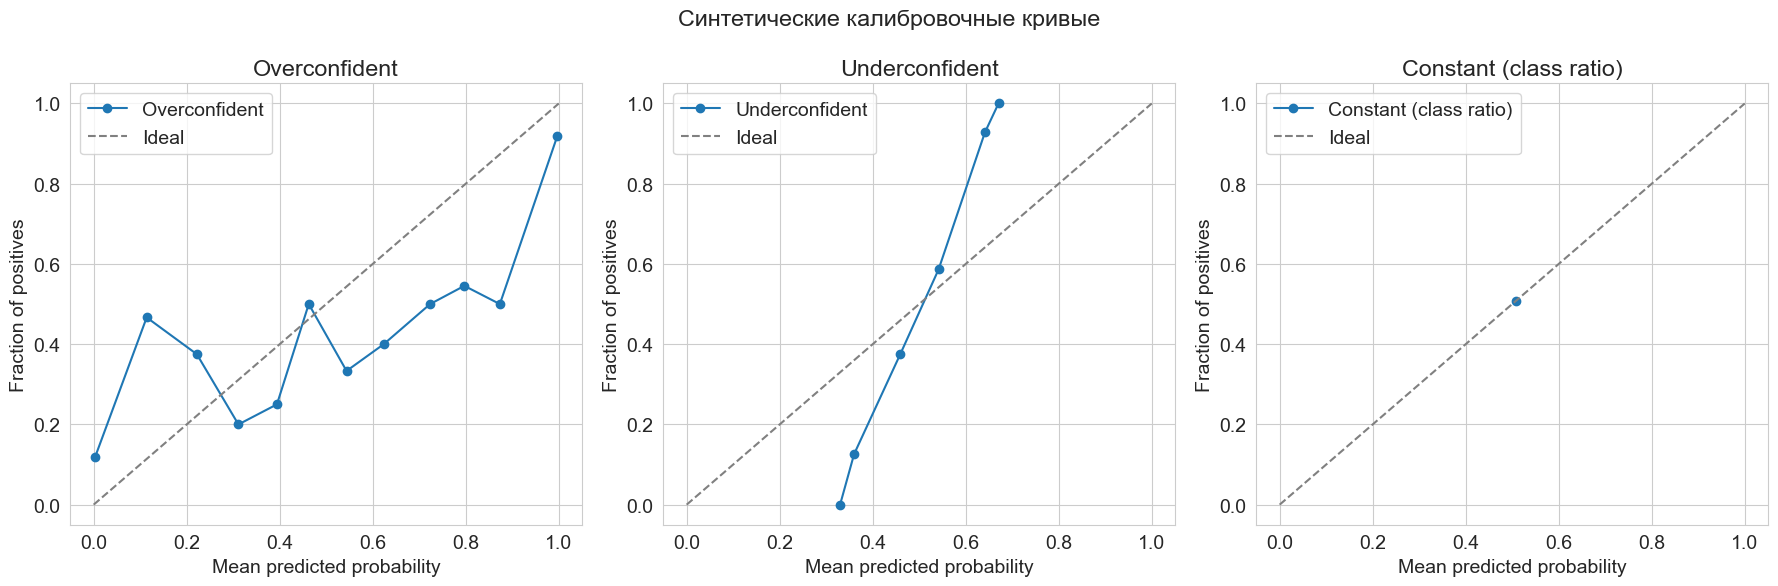

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
for ax, probs, label in zip(axs, [p_over, p_under, p_constant], ['Overconfident', 'Underconfident', 'Constant (class ratio)']):
    t, p = calibration_curve(y_te, probs, n_bins=12)
    ax.plot(p, t, marker='o', label=label)
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ideal')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(label)
    ax.legend()
plt.suptitle('Синтетические калибровочные кривые')
plt.tight_layout()
plt.show()

In [4]:
data = pd.read_csv(r"C:\Users\annap\VSCode\python\nikolskaya\spbu_ml_2026\additional_materials\datasets\ml\riceClassification.csv")


Отмасштабируем данные и подготовим трейн и тест.

In [5]:
X = data.drop(columns=['id', 'Class'])
y = data.Class

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=999)
scaler = StandardScaler().fit(X_train, y_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

**Задание**: Оцените сбалансированность классов

In [6]:
print("Train class distribution:\n", y_train.value_counts(normalize=True))
print("Test class distribution:\n", y_test.value_counts(normalize=True))

Train class distribution:
 Class
1    0.549446
0    0.450554
Name: proportion, dtype: float64
Test class distribution:
 Class
1    0.548529
0    0.451471
Name: proportion, dtype: float64


Классы сбалансированы хорошо. Доля класса 1 примерно 55%, класса 0 где-то 45%.

Обучим метод опорных векторов (SVC — Support Vector Classification) и логистическую регрессию, в качестве метрики возьмем ROC-AUC. Для сравнения также посмотрим на градиентный бустинг.
В качестве скоров будем рассматривать выход decision_function. Этот метод возвращает confidence score для семплов и пропорционален расстоянию до разделяющей гиперплоскости, взятого со знаком. Он вернет матрицу размера (n_samples, n_classes). В бинарном случае, будет возвращен скор для класса 1.

Вопрос: Какая формула для decision function у логистической регрессии?
Ответ: линейная комбинация признаков f(x)=w^T*x+b

In [7]:
svc = LinearSVC(max_iter=100000, C=0.1).fit(X_train, y_train)
svc_pred = svc.decision_function(X_test)
print('SVC ROC-AUC:', roc_auc_score(y_test, svc_pred))

SVC ROC-AUC: 0.9991453206707389


In [8]:
svc_pred

array([ 3.25919713,  1.95223252,  1.93751674, ...,  0.46630054,
        2.95728847, -1.77506552], shape=(7274,))

In [9]:
svc.predict(X_test)

array([1, 1, 1, ..., 1, 1, 0], shape=(7274,))

In [10]:
print('SVC ROC-AUC (on predictions):', roc_auc_score(y_test, svc.predict(X_test)))

SVC ROC-AUC (on predictions): 0.9894067537906887


SVC ROC-AUC (min-max scaled): 0.9991453206707389
SVC ROC-AUC (calibrated): 0.9991402837178207


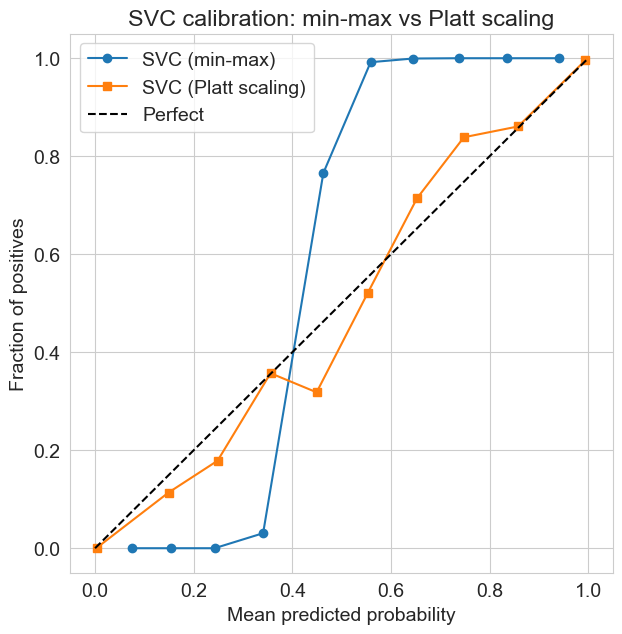

In [22]:
# предскажите вероятности с помощью SVM
from sklearn.calibration import CalibratedClassifierCV

svc_base = LinearSVC(max_iter=100000, C=0.1, random_state=SEED)
svc_calibrated = CalibratedClassifierCV(svc_base, method='sigmoid', cv=5)
svc_calibrated.fit(X_train, y_train)
svc_proba_calib = svc_calibrated.predict_proba(X_test)[:, 1]
print('SVC ROC-AUC (min-max scaled):', roc_auc_score(y_test, svc_pred))
print('SVC ROC-AUC (calibrated):', roc_auc_score(y_test, svc_proba_calib))

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
prob_true_mm, prob_pred_mm = calibration_curve(y_test, svc_pred, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_test, svc_proba_calib, n_bins=10)
ax.plot(prob_pred_mm, prob_true_mm, marker='o', label='SVC (min-max)')
ax.plot(prob_pred_cal, prob_true_cal, marker='s', label='SVC (Platt scaling)')
ax.plot([0,1], [0,1], 'k--', label='Perfect')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.legend()
plt.title('SVC calibration: min-max vs Platt scaling')
plt.show()

In [23]:
lr = LogisticRegression(max_iter=100000, C=0.1).fit(X_train, y_train)
lr_pred = lr.decision_function(X_test)
print('Logistic regression ROC-AUC:', roc_auc_score(y_test, lr_pred))

Logistic regression ROC-AUC: 0.9990017675125695


In [24]:
gb = GradientBoostingClassifier(n_estimators=300, max_depth=3, random_state=SEED).fit(X_train, y_train)
gb_pred = gb.decision_function(X_test) # gb.predict_proba(X_test)[:, 1]
print('Gradient Boosting ROC-AUC:', roc_auc_score(y_test, gb_pred))

Gradient Boosting ROC-AUC: 0.9983573809676445


У случайного леса нет метода decision_function, поэтому просто посмотрим на точность.

In [25]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED).fit(X_train, y_train)
rf_pred = rf.predict_proba(X_test)[:, 1]
print('Random Forest ROC-AUC:', roc_auc_score(y_test, rf_pred))

Random Forest ROC-AUC: 0.9991008275866279


In [26]:
lr.predict(X_test)

array([1, 1, 1, ..., 1, 1, 0], shape=(7274,))

In [27]:
lr.predict_proba(X_test)

array([[7.52180938e-05, 9.99924782e-01],
       [2.37484102e-03, 9.97625159e-01],
       [4.28557243e-03, 9.95714428e-01],
       ...,
       [1.72933989e-01, 8.27066011e-01],
       [2.10618110e-04, 9.99789382e-01],
       [9.98955458e-01, 1.04454161e-03]], shape=(7274, 2))

In [28]:
lr.classes_

array([0, 1])

Судя по метрикам, мы практически идеально предсказываем класс всеми моделями.

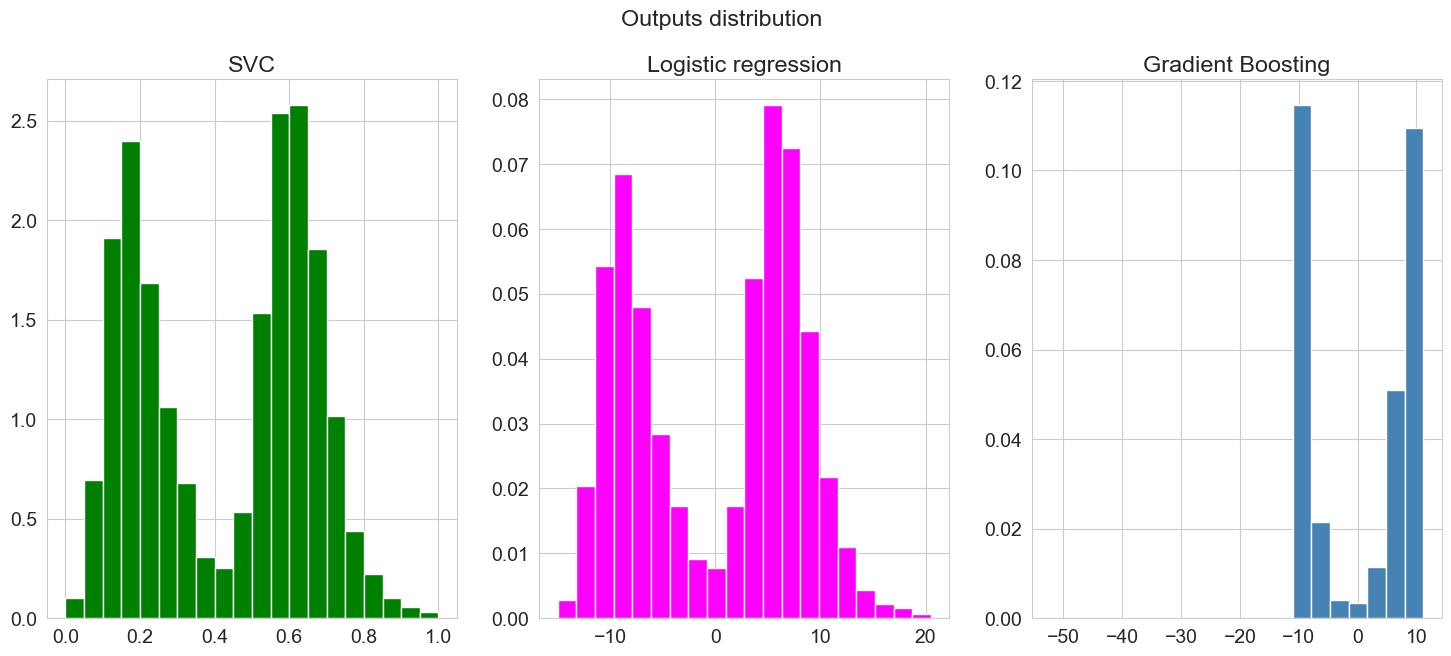

In [29]:
fig, axs = plt.subplots(1, 3, figsize=(18, 7))

axs[0].hist(svc_pred, bins=20, color='green', density='True')
axs[1].hist(lr_pred, bins=20, color='magenta', density='True')
axs[2].hist(gb_pred, bins=20, color='steelblue', density='True')

axs[0].set_title('SVC')
axs[1].set_title('Logistic regression')
axs[2].set_title('Gradient Boosting')

plt.suptitle('Outputs distribution')
plt.show()

Мы видим, что скоры могут принимать любые вещественные значения. Но для оценивания вероятностей нам нужно перевести их в промежуток 
$[0,1]$. С логистической регрессией несложно: можно добавить сигмоиду или софтмакс, ведь модель и обучалась так, чтобы $\sigma (W^Tx)$
 приближало вероятности. Для SVC у нас нет такой опции, поэтому воспользуемся масштабированием через минимум-максимум.

Вопрос: а как вычисляются вероятности для бустинга?
Ответ: сначала вычисляется сумма значений по всем деревьям (сырой отклик, raw score). Затем этот отклик преобразуется в вероятность с помощью логистической функции (сигмоиды):
p=1/(1+e^(−F(x)))​.
Именно это возвращает метод predict_proba.

In [30]:
svc_pred = (svc_pred - svc_pred.min()) / (svc_pred.max() - svc_pred.min())
lr_pred = lr.predict_proba(X_test)[:, 1]
gb_pred = gb.predict_proba(X_test)[:, 1]
rf_pred = rf.predict_proba(X_test)[:, 1]

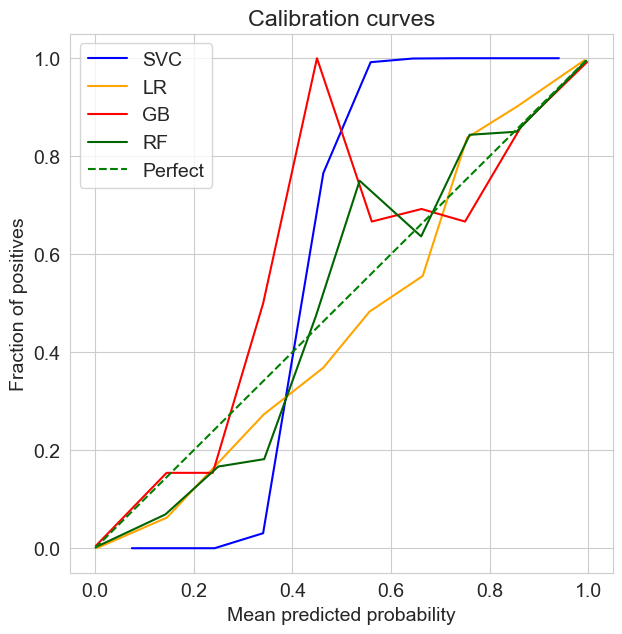

In [31]:
plt.figure(figsize=(7, 7))

svc_true_prob, svc_pred_prob = calibration_curve(y_test, svc_pred, n_bins=10)
lr_true_prob, lr_pred_prob = calibration_curve(y_test, lr_pred, n_bins=10)
gb_true_prob, gb_pred_prob = calibration_curve(y_test, gb_pred, n_bins=10)
rf_true_prob, rf_pred_prob = calibration_curve(y_test, rf_pred, n_bins=10)

plt.plot(svc_pred_prob, svc_true_prob, label='SVC', color='blue')
plt.plot(lr_pred_prob, lr_true_prob, label='LR', color='orange')
plt.plot(gb_pred_prob, gb_true_prob, label='GB', color='red')
plt.plot(rf_pred_prob, rf_true_prob, label='RF', color='darkgreen')
plt.plot([0, 1], [0, 1], label='Perfect', linestyle='--', color='green')

plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration curves')
plt.legend()
plt.show()


Мы видим, что кривая для логистической регрессии неплохо приближает диагональ, при этом в бустинге можно вообразить чрезмерную уверенность. С SVC все гораздо хуже. Но попробуем откалибровать модели разными способами.

Что интересно с ансамблями: у них есть явный горб посередине интервала. Это значит, что моделям в принципе сложновато предсказывать крайние значения вероятностей. Хорошее объяснение этому дано в [статье](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://www.cs.cornell.edu/~alexn/papers/calibration.icml05.crc.rev3.pdf), цитата из нее: 
> Methods such as bagging and random forests that average predictions from a base set of models can have difficulty making predictions near 0 and 1 because variance in the underlying base models will bias predictions that should be near zero or one away from these values. Because predictions are restricted to the interval [0,1], errors caused by variance tend to be one-sided near zero and one. 

> For example, if a model should predict $p=0$ for a case, the only way bagging can achieve this is if all bagged trees predict zero. If we add noise to the trees that bagging is averaging over, this noise will cause some trees to predict values larger than 0 for this case, thus moving the average prediction of the bagged ensemble away from 0. We observe this effect most strongly with random forests because the base-level trees trained with random forests have relatively high variance due to feature subsetting.”

Другой способ визуализировать то же самое - диаграмма надёжности (reliability diagram):

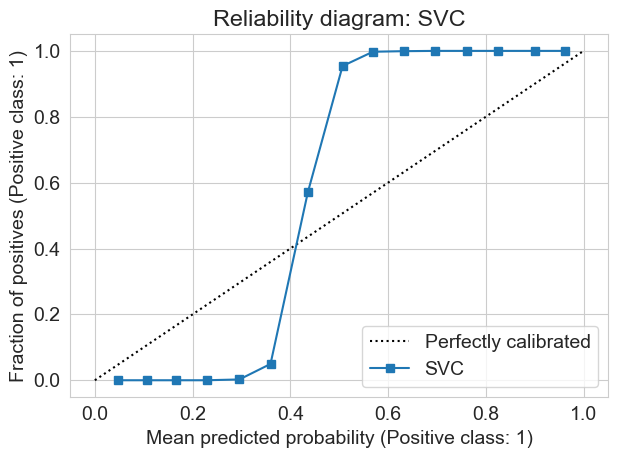

In [32]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_predictions(y_test, svc_pred, n_bins=15, name='SVC')
plt.title('Reliability diagram: SVC')
plt.tight_layout()
plt.show()

**Задание**: Постройте гистограмму предсказанных вероятностей для двух классификаторов.

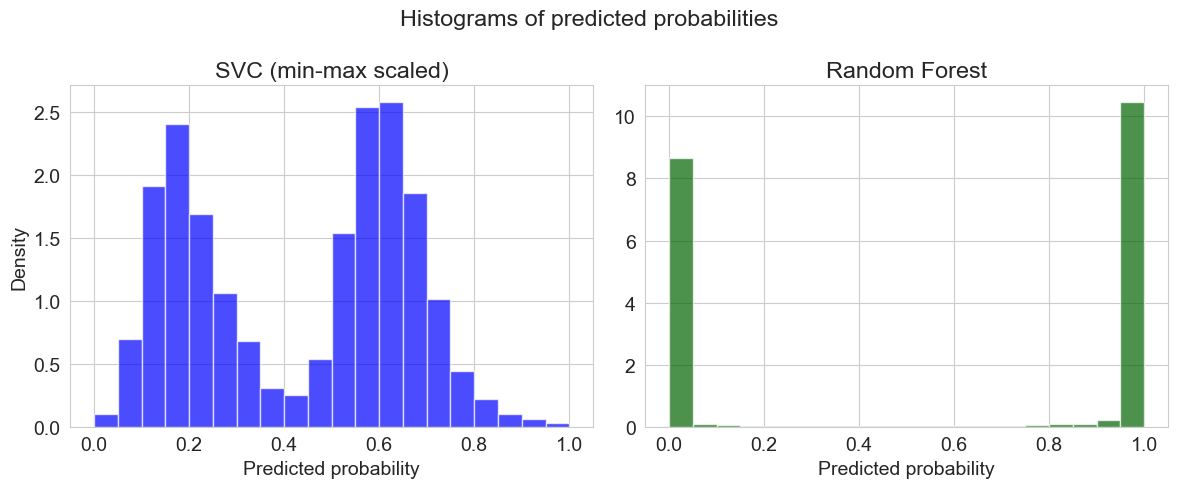

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(svc_pred, bins=20, color='blue', alpha=0.7, density=True)
axes[0].set_title('SVC (min-max scaled)')
axes[0].set_xlabel('Predicted probability')
axes[0].set_ylabel('Density')

axes[1].hist(rf_pred, bins=20, color='darkgreen', alpha=0.7, density=True)
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted probability')

plt.suptitle('Histograms of predicted probabilities')
plt.tight_layout()
plt.show()

# Калибровка Платта
Пусть наш алгоритм выдаёт значения $f(x)$ (могут не быть вероятностями). Тогда итоговая вероятность строится как:

$$P(y = 1 | x) = \frac{1}{1+\exp (af(x) + b)},$$

где $a, b$ -- скалярные параметры. Эти параметры настраиваются методом максимума правдоподобия (минимизируя логистическую функцию потерь):
$$- \sum_{i=1}^N[y_i \log{(\sigma(af(x_i)+b))} + (1 - y_i) \log{(1-\sigma(af(x_i)+b))}] \to min_{a,b}$$

Алгоритм: на выходах $f(x)$ базовой модели обучается логистическая регрессия без регуляризации; откалиброванное предсказание — $\sigma(af(x)+b)$.

Вопрос: на какой выборке обучается модель?

Также Платт предложил для избежания переобучения изменить метки объектов в NLL ($y_i$ и $1-y_i$) на следующие значения:

$t_{+} = \frac{N_{+} + 1}{N_{-} + 2}$ для положительных примеров и

$t_{-} = \frac{1}{N_{-} + 2}$ для отрицательных, где $N_{-}$ и $N_{+}$ число негативных и позитивных семплов в выборке. 

Калибровку Платта можно представить как применение логистической регрессии поверх предсказаний другого алгоритма с отключенной регуляризацией. 

Калибровка Платта неплохо справляется с SVM, но для более хитрых классификаторов может спасовать. В целом, можно показать, что этот метод хорошо работает, если для каждого из истинных классов предсказанные вероятности распределены нормально с одинаковыми дисперсиями (подробнее [здесь](https://research-information.bris.ac.uk/ws/portalfiles/portal/154625753/Full_text_PDF_final_published_version_.pdf)). 

Вообще эта калибровка относится к большой группе параметрических методов калибрации, туда же относится бета-калибрация (в предположении бета-распределения) или калибрация Дирихле (для мультикласса). 

In [35]:
sigmoid_svc = CalibratedClassifierCV(svc, cv=3, method='sigmoid').fit(X_train, y_train)
sigmoid_svc_pred = sigmoid_svc.predict_proba(X_test)[:, 1]
print('SVC ROC-AUC:', roc_auc_score(y_test, sigmoid_svc_pred))

SVC ROC-AUC: 0.9991337204155334


In [36]:
sigmoid_lr = CalibratedClassifierCV(lr, cv=3, method='sigmoid').fit(X_train, y_train)# YOUR CODE: make the same for LR
sigmoid_lr_pred = sigmoid_lr.predict_proba(X_test)[:, 1]
print('Logistic regression ROC-AUC:', roc_auc_score(y_test, sigmoid_lr_pred))

Logistic regression ROC-AUC: 0.9989783380497528


In [37]:
sigmoid_rf = CalibratedClassifierCV(rf, cv=3, method='sigmoid').fit(X_train, y_train)# YOUR CODE: make the same for LR
sigmoid_rf_pred = sigmoid_rf.predict_proba(X_test)[:, 1]
print('LRandom forest ROC-AUC:', roc_auc_score(y_test, sigmoid_rf_pred))

LRandom forest ROC-AUC: 0.999082664029135


In [38]:
sigmoid_gb = CalibratedClassifierCV(gb, cv=3, method='sigmoid').fit(X_train, y_train)
sigmoid_gb_pred = sigmoid_gb.predict_proba(X_test)[:, 1]
print('Gradient Boosting ROC-AUC:', roc_auc_score(y_test, sigmoid_gb_pred))

Gradient Boosting ROC-AUC: 0.9990612569792324


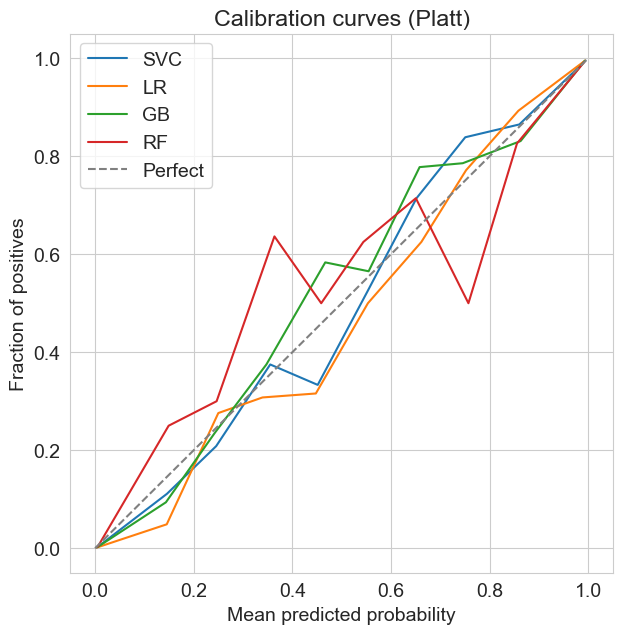

In [39]:
plt.figure(figsize=(7, 7))
for name, pred in [('SVC', sigmoid_svc_pred), ('LR', sigmoid_lr_pred), ('GB', sigmoid_gb_pred), ('RF', sigmoid_rf_pred)]:
    true_prob, pred_prob = calibration_curve(y_test, pred, n_bins=10)
    plt.plot(pred_prob, true_prob, label=name)
plt.plot([0, 1], [0, 1], label='Perfect', linestyle='--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration curves (Platt)')
plt.legend()
plt.show()

Как мы видим, калибровка Платта действительно улучшила вероятности, который получаются у SVC, RF и GB. При этом кривая для логистической регрессии практически не сдвигается. 

# Изотоническая регрессия
В этом методе также строится отображение из предсказаний модели в откалиброванные вероятности. Используется изотоническая функция: неубывающая, кусочно-постоянная; $x$ — выходы алгоритма, $y$ — целевая переменная. 

Мы хотим найти такую функцию $m(t)$: $P(y = 1 | x) = m(f(x))$. Она настраивается под квадратичную ошибку:

$$m = \arg \min_{z} \sum (y_i - z(f(x_i))^2,$$

с помощью специального алгоритма (Pool-Adjacent-Violators Algorithm):

---
*Вход: обучающая выборка — пары (скор модели $f_i$, метка $y_i \in \{0,1\}$), отсортированные по возрастанию $f_i$.*

Для каждой точки $i$ задаём один сегмент: оценка вероятности сегмента $m_{i,i} = y_i$ (метка точки), вес сегмента $w_{i,i} = 1$.

В цикле, пока есть нарушение изотонности — два соседних сегмента $(k, i-1)$ и $(i, l)$, у которых $m_{k,i-1} \geq m_{i,l}$ — объединяем их в один $(k, l)$: новый вес $w_{k,l} = w_{k,i-1} + w_{i,l}$, новая оценка $m_{k,l} = (w_{k,i-1} m_{k,i-1} + w_{i,l} m_{i,l}) / w_{k,l}$; заменяем два старых сегмента одним и повторяем.

*Выход: кусочно-постоянная функция $m(f)$: для любого скора $f$ значение $m(f)$ — это $m_{i,j}$ того сегмента $(i,j)$, в диапазон которого попадает $f$.*

---

В результате калибровки получаем надстройку над нашей моделью, которая применяется поверх предсказаний базовой модели. В случае мультиклассовой классификации каждый класс калибруется отдельно против остальных (one-versus-all), вероятности при предсказании нормируются.

Этот метод более общий, чем калибровка Платта, так как единственное условие для калибровочной функции - чтобы она была изотонической. Этот метод склонен к переобучению, поэтому его рекомендуется применять только для больших выборок.


In [40]:
isotonic_svc = CalibratedClassifierCV(svc, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_svc_pred = isotonic_svc.predict_proba(X_test)[:, 1]
print('SVC ROC-AUC:', roc_auc_score(y_test, isotonic_svc_pred))

SVC ROC-AUC: 0.9990992249197903


In [41]:
# YOUR CODE: Make the same for LR
isotonic_lr = CalibratedClassifierCV(lr, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_lr_pred = isotonic_lr.predict_proba(X_test)[:, 1]
print('LR ROC-AUC:', roc_auc_score(y_test, isotonic_svc_pred))

LR ROC-AUC: 0.9990992249197903


In [42]:
isotonic_gb = CalibratedClassifierCV(gb, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_gb_pred = isotonic_gb.predict_proba(X_test)[:, 1]
print('Gradient Boosting ROC-AUC:', roc_auc_score(y_test, isotonic_gb_pred))

Gradient Boosting ROC-AUC: 0.998995204210282


In [43]:
isotonic_rf = CalibratedClassifierCV(rf, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_rf_pred = isotonic_rf.predict_proba(X_test)[:, 1]
print('Random Forest ROC-AUC:', roc_auc_score(y_test, isotonic_rf_pred))

Random Forest ROC-AUC: 0.9991284163514756


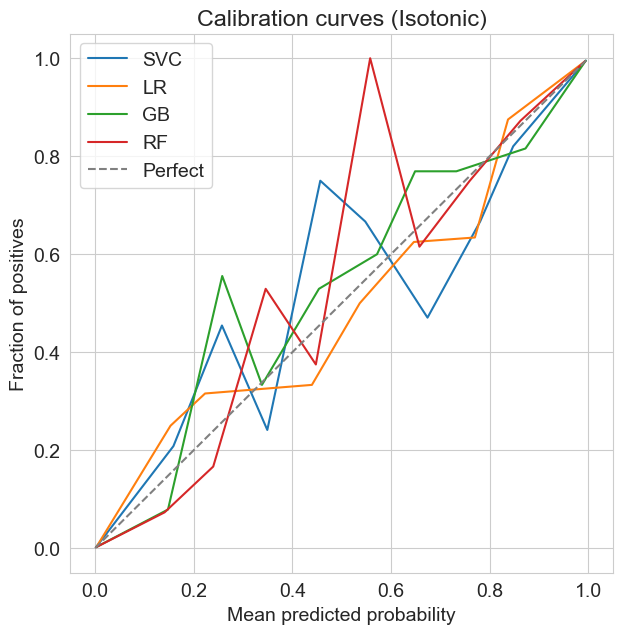

In [44]:
plt.figure(figsize=(7, 7))
for name, pred in [('SVC', isotonic_svc_pred), ('LR', isotonic_lr_pred), ('GB', isotonic_gb_pred), ('RF', isotonic_rf_pred)]:
    true_prob, pred_prob = calibration_curve(y_test, pred, n_bins=10)
    plt.plot(pred_prob, true_prob, label=name)
plt.plot([0, 1], [0, 1], label='Perfect', linestyle='--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration curves (Isotonic)')
plt.legend()
plt.show()

Изотоническая регрессия немного подпортила кривую калибрации для моделей. Судя по всему, олна переобучилась.

## Мультикласс
У нас есть как минимум три варианта определить, что означает мультиклассовая калиброванность. Например, по мере увеличения строгости:
1) Учитывать только самую высокую вероятность. Для него мы требуем, чтобы среди всех случаев, где вероятность наиболее вероятного класса прогнозируется как $c$, ожидаемая точность была бы $c$. $P(Y=i|\hat p_i(x)=q_i)=q_i, i=\arg\max_j \hat p_j (X)$
2) Учитывать маргинальные вероятности. Тут мы хотим, чтобы все one-vs-rest вероятности были откалиброваны: $P(Y=i|\hat p_i(x)=q_i)=q_i, i=1...k$.
3) Учитывать весь вектор вероятностей. Т.е. чтобы пропорции классов для семплов с определенным вектором предсказаний былит такие же, как и весь вектор предсказаний:  $P(Y=i|\hat p(x)=q)=q_i, i=1...k$. 
   
Чаще всего используется определение слабой калиброванности (1). Однако, в случае чувствительной к стоимости постановки задачи оно может быть слишком слабым.


## Оценка качества калибровки

Мы что-то поняли по графикам, но как оценить численно улучшение предсказания вероятностей? Для этого есть свои метрики.

**Maximum calibration error**. Самый простой способ, впрочем — он наследник идеи с калибровочной кривой. А именно, разобьём отрезок 
$[0,1]$ на бины $B_1, B_2, ..., B_k$ по предсказанным вероятностям $\overline y(x_i)$ и вычислим следующее:
$$ \max_{j=1,..,k}|{\overline y(B_k) - \overline q (B_k) }|$$
Где $\overline y(B_k) $ - средняя предсказанная вероятность, $ \overline q (B_k) $ - среднее значение уверенности.

**Expected Calibration Error (ECE)** считает среднюю разницу: $$ \sum^k_{j=1}{{\|B_j\|}\over{N}}{| {\overline y(B_k) - \overline q (B_k) }|},$$
где $\|B_j\|$ - число семплов в бине. Бинны обычно строят равными по длине отрезка $[0,1]$ (uniform) или по квантилям предсказаний (quantile); веса $|B_j|/N$ делают вклад каждого бина пропорциональным его размеру.

Проблема этих способов в том, что мы можем очень по-разному предсказывать в каждом из бинов вероятности (в том числе константой) без ущерба для метрики.

Применим метрику калибрации:

In [45]:
def binary_ECE(y_true: np.ndarray, y_prob: np.ndarray, n_bins: int = 10) -> float:
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n = len(y_true)
    for i in range(n_bins):
        low, high = bin_edges[i], bin_edges[i + 1]
        mask = (y_prob >= low) & (y_prob <= high) if i == n_bins - 1 else (y_prob >= low) & (y_prob < high)
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += mask.sum() * np.abs(acc - conf)
    return ece / n

print("Platt:")
print('SVC binary-ECE = ', binary_ECE(y_test, sigmoid_svc_pred))
print('Linear binary-ECE = ', binary_ECE(y_test, sigmoid_lr_pred))
print('GB binary-ECE = ', binary_ECE(y_test, sigmoid_gb_pred))
print('RF binary-ECE = ', binary_ECE(y_test, sigmoid_rf_pred))

print("Isotonic:")
print('SVC binary-ECE = ', binary_ECE(y_test, isotonic_svc_pred))
print('Linear binary-ECE = ', binary_ECE(y_test, isotonic_lr_pred))
print('GB binary-ECE = ', binary_ECE(y_test, isotonic_gb_pred))
print('RF binary-ECE = ', binary_ECE(y_test, isotonic_rf_pred))

Platt:
SVC binary-ECE =  0.0027822956798889934
Linear binary-ECE =  0.0034477460600426638
GB binary-ECE =  0.003472623806893145
RF binary-ECE =  0.002610568433671964
Isotonic:
SVC binary-ECE =  0.0020864508068445986
Linear binary-ECE =  0.002150623426981368
GB binary-ECE =  0.002283717139315842
RF binary-ECE =  0.002056138427129562


Может быть такое, что метрики показывают нам иную картину, чем графики. Возможно, дело в том, что мы делали графики без учета числа семплов в бинах (а резкие прыжки могут значить, что семплов маловато). 

**Задание**: постройте калибровочные кривые для адаптивных бинов (strategy=‘quantile’) и сравните графики для разных калибровок с ними.

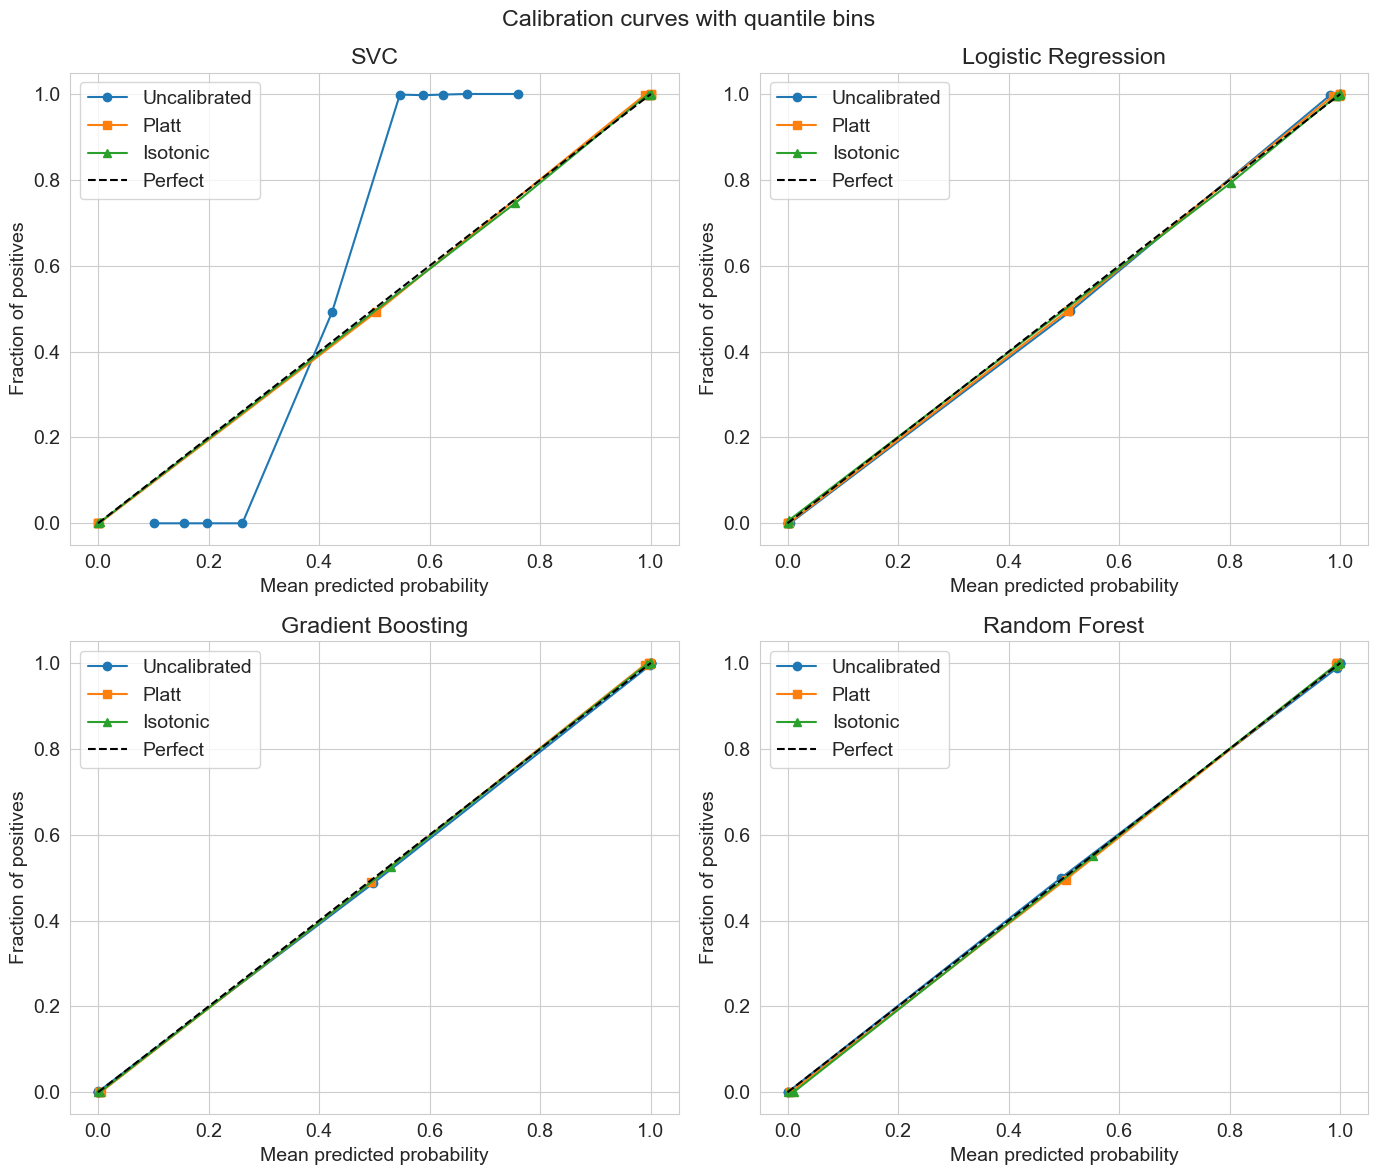

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
models = [
    ('SVC', svc_pred, sigmoid_svc_pred, isotonic_svc_pred),
    ('Logistic Regression', lr_pred, sigmoid_lr_pred, isotonic_lr_pred),
    ('Gradient Boosting', gb_pred, sigmoid_gb_pred, isotonic_gb_pred),
    ('Random Forest', rf_pred, sigmoid_rf_pred, isotonic_rf_pred)
]
for ax, (name, raw, platt, iso) in zip(axes.ravel(), models):
    prob_true_raw, prob_pred_raw = calibration_curve(y_test, raw, n_bins=10, strategy='quantile')
    prob_true_platt, prob_pred_platt = calibration_curve(y_test, platt, n_bins=10, strategy='quantile')
    prob_true_iso, prob_pred_iso = calibration_curve(y_test, iso, n_bins=10, strategy='quantile')
    
    ax.plot(prob_pred_raw, prob_true_raw, 'o-', label='Uncalibrated')
    ax.plot(prob_pred_platt, prob_true_platt, 's-', label='Platt')
    ax.plot(prob_pred_iso, prob_true_iso, '^-', label='Isotonic')
    ax.plot([0,1], [0,1], 'k--', label='Perfect')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(name)
    ax.legend()
plt.suptitle('Calibration curves with quantile bins')
plt.tight_layout()
plt.show()

**Задание**: Посчитайте метрику для неоткалиброванного классификатора.

In [50]:
print("Неоткалиброванные модели:")
print('SVC бинарный есе = ', binary_ECE(y_test, svc_pred))
print('LR бинарный есе = ', binary_ECE(y_test, lr_pred))
print('GB бинарный есе = ', binary_ECE(y_test, gb_pred))
print('RF бинарный есе = ', binary_ECE(y_test, rf_pred))

Неоткалиброванные модели:
SVC бинарный есе =  0.2853463663126201
LR бинарный есе =  0.006611511041150998
GB бинарный есе =  0.005608642861334207
RF бинарный есе =  0.0025606234517145886


**Вопрос**: Как можно адаптировать MCE/ECE для мультиклассовой задачи? Напишите формулы.
*Ответ*: использовать выигравший класс. Можно сделать бинарные есе для всех классов и потом усреднить по классам.

В случае мультикласса, у нас возникает несколько сложностей: во-первых, в случае большого числа классов число бинов будет очень большим, при этом многие будут пустыми. Да и само определение реальной ECE пока не сделано. 

**Задание:** посчитайте ECE для модели, которая предсказывает пропорцию классов. Какие знаечения ECE и лосса у нее будут? Что изменится, если модель начнет предсказывать 0.9 для позитивных семплов и продолжит предсказывать пропорцию классов для негадивных?

In [53]:
# 1
y_mean = y_test.mean()
const_pred = np.full_like(y_test, y_mean, dtype=float)
# 2
mixed_pred = np.where(y_test == 1, 0.9, y_mean)
print("константная модель (предсказывает соотношение классов):")
print(f"ECE = {binary_ECE(y_test, const_pred):.4f}")
print(f"Log лосс = {log_loss(y_test, const_pred):.4f}\n")
print("Смешанная модель (0.9 для положительных, соотношение для отрицательных):")
print(f"ECE = {binary_ECE(y_test, mixed_pred):.4f}")
print(f"Log лосс = {log_loss(y_test, mixed_pred):.4f}")

константная модель (предсказывает соотношение классов):
ECE = 0.0000
Log лосс = 0.6884

Смешанная модель (0.9 для положительных, соотношение для отрицательных):
ECE = 0.3025
Log лосс = 0.4168


Можно посчитать калиброванность и на уровне семплов.

**Brier score.** Тоже одна из популярных метрик, которая попросту измеряет разницу между предсказанными вероятностями и $ y_i $ (обратите внимание, что $ y_i $  - это либо 0, либо 1):
$$ \sum^N_{i=1}(y_i - q (x_i))^2,$$ 
для бинарного случая, и
$$ {1 \over N} \sum^N_{n=1}\sum^K_{j=1} (I(y_n=j) - q_{nj})^2,$$ 
для мультикласса.

**Вопрос**: Какое значение соответствует лучшей калибрации? Какие максимальные и минимальные значения он можеит принимать?

Также можно использовать log-loss:
$$ {-1\over N} {\sum^N_{n=1}\sum^K_{j=1}I(y_n=j)log(q_{n,j})}$$

Для достаточно гладких классификатора и датасета brier score и log-loss будут адекватными средствами оценки, но если нет — возможно всякое.

In [54]:
print('Log-loss (ниже — лучше):')
print('Platt SVC =', log_loss(y_test, np.column_stack([1 - sigmoid_svc_pred, sigmoid_svc_pred])))
print('Platt LR =', log_loss(y_test, np.column_stack([1 - sigmoid_lr_pred, sigmoid_lr_pred])))
print('Platt GB =', log_loss(y_test, np.column_stack([1 - sigmoid_gb_pred, sigmoid_gb_pred])))
print('Platt RF =', log_loss(y_test, np.column_stack([1 - sigmoid_rf_pred, sigmoid_rf_pred])))
print('Isotonic SVC =', log_loss(y_test, np.column_stack([1 - isotonic_svc_pred, isotonic_svc_pred])))
print('Isotonic LR =', log_loss(y_test, np.column_stack([1 - isotonic_lr_pred, isotonic_lr_pred])))
print('Isotonic GB =', log_loss(y_test, np.column_stack([1 - isotonic_gb_pred, isotonic_gb_pred])))
print('Isotonic RF =', log_loss(y_test, np.column_stack([1 - isotonic_rf_pred, isotonic_rf_pred])))

Log-loss (ниже — лучше):
Platt SVC = 0.031276285531666545
Platt LR = 0.0333262455198998
Platt GB = 0.03331647881716411
Platt RF = 0.038908642002126646
Isotonic SVC = 0.030862017939829182
Isotonic LR = 0.033625055910619976
Isotonic GB = 0.03191541409933446
Isotonic RF = 0.0317766445159259


In [55]:
print("Platt:")
print('SVC brier score = ', brier_score_loss(y_test, sigmoid_svc_pred, pos_label=1))
print('Linear brier score = ', brier_score_loss(y_test, sigmoid_lr_pred, pos_label=1))
print('GB brier score = ', brier_score_loss(y_test, sigmoid_gb_pred, pos_label=1))
print('RF brier score = ', brier_score_loss(y_test, sigmoid_rf_pred, pos_label=1))

print("Isotonic:")
print('SVC brier score = ', brier_score_loss(y_test, isotonic_svc_pred, pos_label=1))
print('Linear brier score = ', brier_score_loss(y_test, isotonic_lr_pred, pos_label=1))
print('GB brier score = ', brier_score_loss(y_test, isotonic_gb_pred, pos_label=1))
print('RF brier score = ', brier_score_loss(y_test, isotonic_rf_pred, pos_label=1))

Platt:
SVC brier score =  0.008190798964847236
Linear brier score =  0.008657533565358946
GB brier score =  0.008325371462496654
RF brier score =  0.008416712034272293
Isotonic:
SVC brier score =  0.008210667087880846
Linear brier score =  0.008753390327467456
GB brier score =  0.008318772289237032
RF brier score =  0.008147859165350083


**Задание**: Посчитайте метрику для неоткалиброванного классификатора.

In [56]:
print("Неоткалиброванные модели:")
print("Log-loss:")
print(f"SVC (min-max) log-loss = {log_loss(y_test, np.column_stack([1-svc_pred, svc_pred])):.4f}")
print(f"Logistic Regression log-loss = {log_loss(y_test, np.column_stack([1-lr_pred, lr_pred])):.4f}")
print(f"Gradient Boosting log-loss = {log_loss(y_test, np.column_stack([1-gb_pred, gb_pred])):.4f}")
print(f"Random Forest log-loss = {log_loss(y_test, np.column_stack([1-rf_pred, rf_pred])):.4f}")

print("\nBrier score:")
print(f"SVC (min-max) Brier = {brier_score_loss(y_test, svc_pred):.4f}")
print(f"Logistic Regression Brier = {brier_score_loss(y_test, lr_pred):.4f}")
print(f"Gradient Boosting Brier = {brier_score_loss(y_test, gb_pred):.4f}")
print(f"Random Forest Brier = {brier_score_loss(y_test, rf_pred):.4f}")

Неоткалиброванные модели:
Log-loss:
SVC (min-max) log-loss = 0.3685
Logistic Regression log-loss = 0.0344
Gradient Boosting log-loss = 0.0459
Random Forest log-loss = 0.0315

Brier score:
SVC (min-max) Brier = 0.1036
Logistic Regression Brier = 0.0087
Gradient Boosting Brier = 0.0088
Random Forest Brier = 0.0081


Итак, мы откалибровали наши классификаторы. Теперь мы можем оценить, как поменяются метрики после этого. Так, по идее точность, f1 не должны сильно поменяться, так как вблизи от границы разделения вероятности не должны сильно измениться. Так ли это?
Теперь **вопрос**: Изменится ли после калибрации ROC-AUC и как? Можете ли вы ответить на вопрос без измерений?

Да, мону, калибровка применяет монотонное преобразование к предсказаниям, которое сохраняет порядок. Следовательно, ROC-AUC не изменится после калибровки

**Задание**: Обучите дерево решений и случайный лес.

In [57]:
from sklearn.tree import DecisionTreeClassifier
# 1
dt = DecisionTreeClassifier(max_depth=5, random_state=SEED)
dt.fit(X_train, y_train)
dt_pred = dt.predict_proba(X_test)[:, 1]  
# 2
rf2 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED)
rf2.fit(X_train, y_train)
rf2_pred = rf2.predict_proba(X_test)[:, 1]
print("Дерево решений и случайный лес обучены.")

Дерево решений и случайный лес обучены.


**Задание**: Откалибройте изотоническим методом. Постройте калибровочные кривые для классификаторов, до и после калибровки.

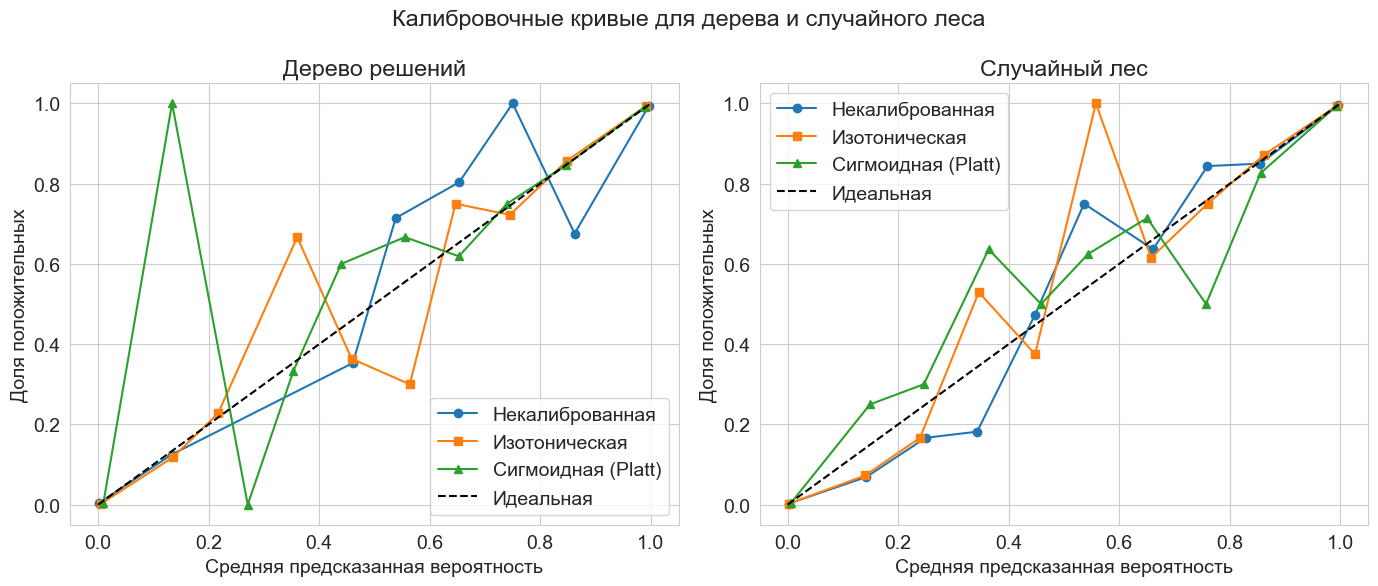

In [59]:
from sklearn.calibration import CalibratedClassifierCV

dt_isotonic = CalibratedClassifierCV(dt, cv=3, method='isotonic').fit(X_train, y_train)
dt_sigmoid = CalibratedClassifierCV(dt, cv=3, method='sigmoid').fit(X_train, y_train)
dt_iso_pred = dt_isotonic.predict_proba(X_test)[:, 1]
dt_sig_pred = dt_sigmoid.predict_proba(X_test)[:, 1]

rf_isotonic = CalibratedClassifierCV(rf2, cv=3, method='isotonic').fit(X_train, y_train)
rf_sigmoid = CalibratedClassifierCV(rf2, cv=3, method='sigmoid').fit(X_train, y_train)
rf_iso_pred = rf_isotonic.predict_proba(X_test)[:, 1]
rf_sig_pred = rf_sigmoid.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, model_name, pred_raw, pred_iso, pred_sig in [
    (axes[0], 'Дерево решений', dt_pred, dt_iso_pred, dt_sig_pred),
    (axes[1], 'Случайный лес', rf2_pred, rf_iso_pred, rf_sig_pred)
]:
    prob_true_raw, prob_pred_raw = calibration_curve(y_test, pred_raw, n_bins=10, strategy='uniform')
    prob_true_iso, prob_pred_iso = calibration_curve(y_test, pred_iso, n_bins=10, strategy='uniform')
    prob_true_sig, prob_pred_sig = calibration_curve(y_test, pred_sig, n_bins=10, strategy='uniform')
    
    ax.plot(prob_pred_raw, prob_true_raw, 'o-', label='Некалиброванная')
    ax.plot(prob_pred_iso, prob_true_iso, 's-', label='Изотоническая')
    ax.plot(prob_pred_sig, prob_true_sig, '^-', label='Сигмоидная (Platt)')
    ax.plot([0,1], [0,1], 'k--', label='Идеальная')
    ax.set_xlabel('Средняя предсказанная вероятность')
    ax.set_ylabel('Доля положительных')
    ax.set_title(model_name)
    ax.legend()
plt.suptitle('Калибровочные кривые для дерева и случайного леса')
plt.tight_layout()
plt.show()

ВОпрос: Какой вывод можно сделать из графиков?
ОТвет: дерево решений после калибровки кривая становится ближе к диагонале, а случайный лес изначально до калибровки показыавает себя лучше

**Задание**: Какой из классификаторов в итоге лучше откалиброван (среди всех)? Покажите в сравнении. Какой вы выберете далее?

In [61]:
models_pred = {
    'SVC (min-max)': svc_pred,
    'SVC Platt': sigmoid_svc_pred,
    'SVC Isotonic': isotonic_svc_pred,
    'LogReg': lr_pred,
    'LogReg Platt': sigmoid_lr_pred,
    'LogReg Isotonic': isotonic_lr_pred,
    'GB': gb_pred,
    'GB Platt': sigmoid_gb_pred,
    'GB Isotonic': isotonic_gb_pred,
    'RF': rf_pred,
    'RF Platt': sigmoid_rf_pred,
    'RF Isotonic': isotonic_rf_pred,
    'DT': dt_pred,
    'DT Platt': dt_sig_pred,
    'DT Isotonic': dt_iso_pred
}

print("Сравнение калибровки всех моделей (ECE и Brier score):")
for name, pred in models_pred.items():
    ece = binary_ECE(y_test, pred, n_bins=10)
    brier = brier_score_loss(y_test, pred)
    print(f"{name:25} ECE = {ece:.6f}  Brier = {brier:.6f}")

Сравнение калибровки всех моделей (ECE и Brier score):
SVC (min-max)             ECE = 0.285346  Brier = 0.103584
SVC Platt                 ECE = 0.002782  Brier = 0.008191
SVC Isotonic              ECE = 0.002086  Brier = 0.008211
LogReg                    ECE = 0.006612  Brier = 0.008709
LogReg Platt              ECE = 0.003448  Brier = 0.008658
LogReg Isotonic           ECE = 0.002151  Brier = 0.008753
GB                        ECE = 0.005609  Brier = 0.008841
GB Platt                  ECE = 0.003473  Brier = 0.008325
GB Isotonic               ECE = 0.002284  Brier = 0.008319
RF                        ECE = 0.002561  Brier = 0.008120
RF Platt                  ECE = 0.002611  Brier = 0.008417
RF Isotonic               ECE = 0.002056  Brier = 0.008148
DT                        ECE = 0.005530  Brier = 0.009585
DT Platt                  ECE = 0.004323  Brier = 0.009098
DT Isotonic               ECE = 0.003851  Brier = 0.008796


Random Forest с изотонической калибровкой самый лучший, у него минимальный есе и один из лучших Brier.
Если важнее Brier, то можно взять SVC Platt или лес без калибровки.

Больше информации - в [отличном туториале](https://classifier-calibration.github.io/ecml-pkdd-2020-tutorial/) и [материалах Дьяконова](https://web.archive.org/web/20240315204907/https://alexanderdyakonov.wordpress.com/2020/03/27/%D0%BF%D1%80%D0%BE%D0%B1%D0%BB%D0%B5%D0%BC%D0%B0-%D0%BA%D0%B0%D0%BB%D0%B8%D0%B1%D1%80%D0%BE%D0%B2%D0%BA%D0%B8-%D1%83%D0%B2%D0%B5%D1%80%D0%B5%D0%BD%D0%BD%D0%BE%D1%81%D1%82%D0%B8/).